# Exploratory Data Analysis (EDA) & Strategic Insights

### Business Objective
To discover hidden patterns in sales and profitability across different dimensions (Discounts, Product Lines, and Geography) and identify core areas where the company is losing margin.

### Methodology
* **Univariate & Bivariate Visualization:** Using `Seaborn` and `Matplotlib` to discover patterns.
* **Hypothesis-Driven Exploration:** Spotting operational leakages to serve as a baseline for deep-dive SQL queries.

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'tahoma'

df = pd.read_csv('D:\DA-project-01-sales-analysis\da-project-01-sales-analysis\data\cleaned\superstore_orders_cleaned.csv')

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
C:\Users\U s e r\AppData\Local\Temp\ipykernel_12820\801848711.py:11: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\DA-project-01-sales-analysis\da-project-01-sales-analysis\data\cleaned\superstore_orders_cleaned.csv')


# Discount vs Profit Analysis

## 1. Discount vs. Profitability Analysis

### Business Context
The sales team often leverages discounts to drive revenue volume. However, aggressive discounting can inadvertently erode profit margins. This analysis aims to identify the exact threshold where discounts stop driving healthy growth and start destroying business value.

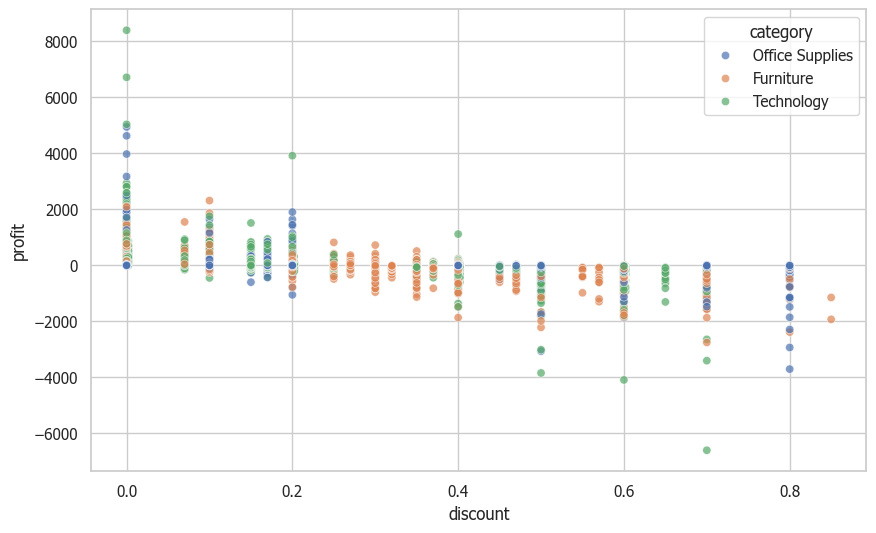

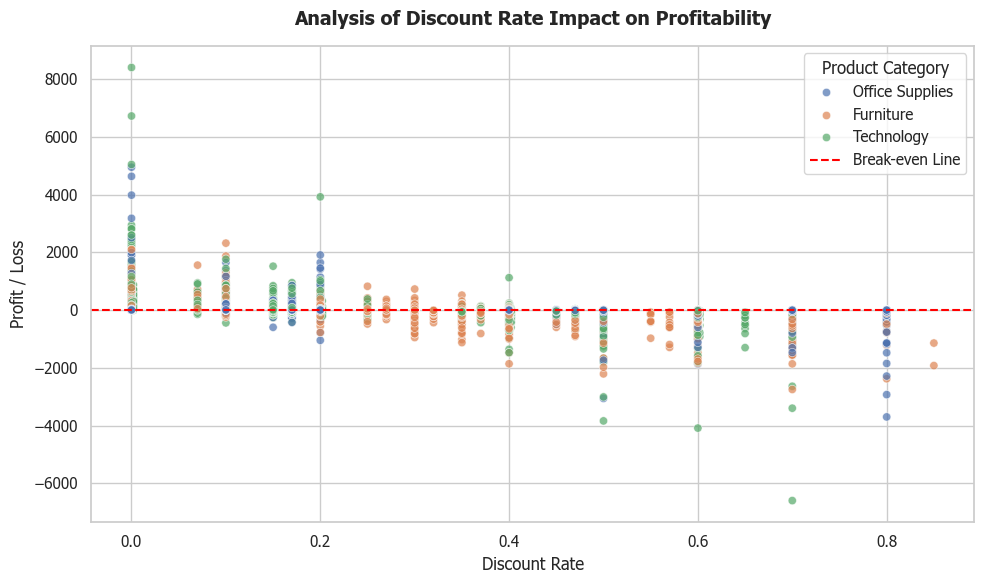

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.7)
# Plotting the relationship between discount and profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.7)

# Add break-even line to clearly distinguish profit from loss
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even Line')

# Labels and styling for business presentation
plt.title('Analysis of Discount Rate Impact on Profitability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit / Loss', fontsize=12)
plt.legend(title='Product Category')

plt.tight_layout()
plt.show()

### Key Findings & Business Insights
* **The Critical Threshold (20%):** The scatter plot reveals a strict pattern. Once the discount rate hits **20% or higher**, almost all orders drop below the red break-even line, resulting in a **100% loss rate**.
* **Business Impact:** High discounts might generate vanity metrics like high sales volume, but they severely damage the bottom-line margin.
* **Actionable Recommendation:** Implement a system-level "Hard Ceiling" in the checkout system to restrict sales representatives from granting discounts above 20% without regional manager approval.

# Sub-category Health Check

## 2. Product Sub-Category Performance

### Business Context
Not all revenue is created equal. A sub-category might look like a top-performer on paper due to high sales volume, but it could actually be a cash drain. We will compare Total Sales against Total Profit side-by-side.

C:\Users\U s e r\AppData\Local\Temp\ipykernel_12820\1612315745.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_analysis, x='sales', y='sub_category', ax=axes[0], palette='Blues_r')
C:\Users\U s e r\AppData\Local\Temp\ipykernel_12820\1612315745.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_analysis, x='profit', y='sub_category', ax=axes[1], palette=colors)


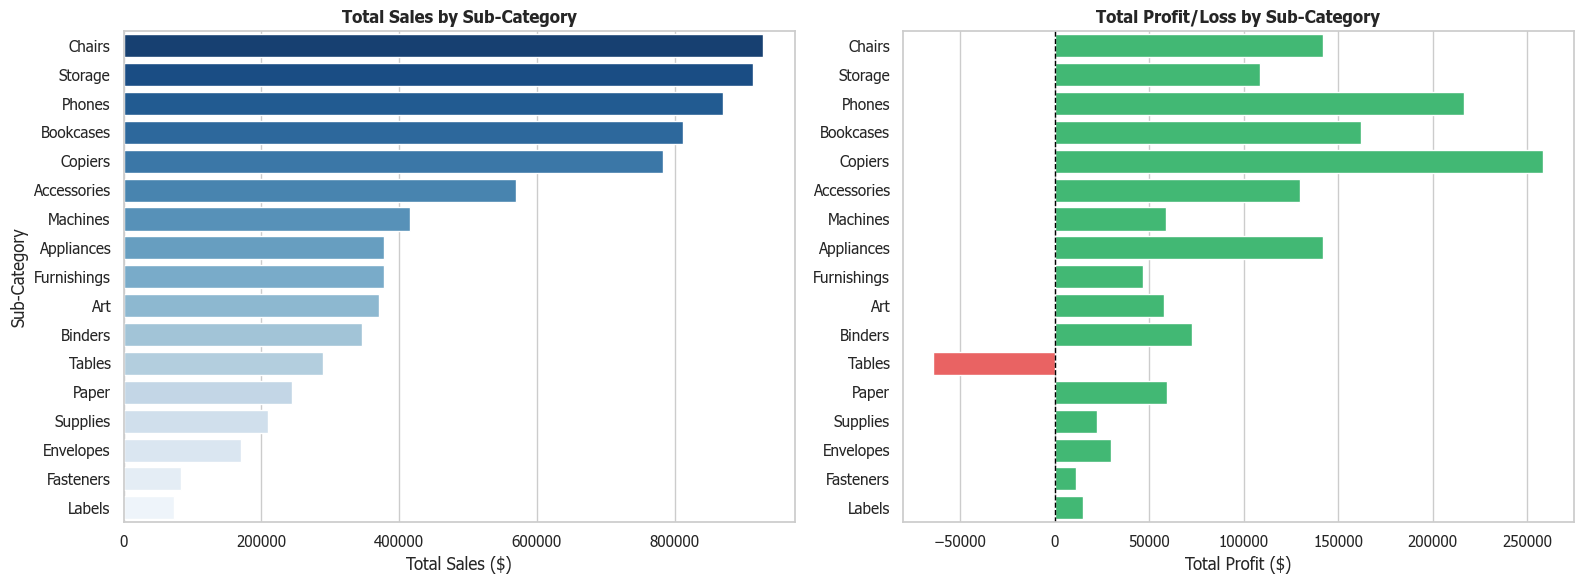

In [10]:
# Aggregate sales and profit by sub-category
sub_cat_analysis = df.groupby('sub_category')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False).reset_index()

# Initialize a side-by-side subplot structure for instant comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Total Sales Performance
sns.barplot(data=sub_cat_analysis, x='sales', y='sub_category', ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Sales by Sub-Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Sub-Category')

# Right Plot: Total Profit/Loss Performance (Red indicates loss, Green indicates profit)
colors = ['#ff4d4d' if x < 0 else '#2ecc71' for x in sub_cat_analysis['profit']]
sns.barplot(data=sub_cat_analysis, x='profit', y='sub_category', ax=axes[1], palette=colors)
axes[1].set_title('Total Profit/Loss by Sub-Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### Key Findings & Business Insights
* **The Revenue Trap ("Tables"):** The **"Tables"** sub-category is one of the top revenue generators (ranking high in sales volume), but it is the **most unprofitable product line** in the entire company, causing massive net losses.
* **Strategic View:** High sales in "Tables" represent an illusion of growth. The company loses money on every table sold.
* **Next Step Hypothesis:** We need to investigate whether this loss is driven by high production/shipping costs or excessive promotional discounting by the sales team.

# Regional Performance Matrix

## 3. Regional Profit Contribution

### Business Context
Geographical expansion is costly. We need to evaluate which regions are efficiently turning sales into actual profits, and which regions are operating inefficiently.

C:\Users\U s e r\AppData\Local\Temp\ipykernel_12820\2364112982.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_analysis, x='region', y='profit', palette='coolwarm')


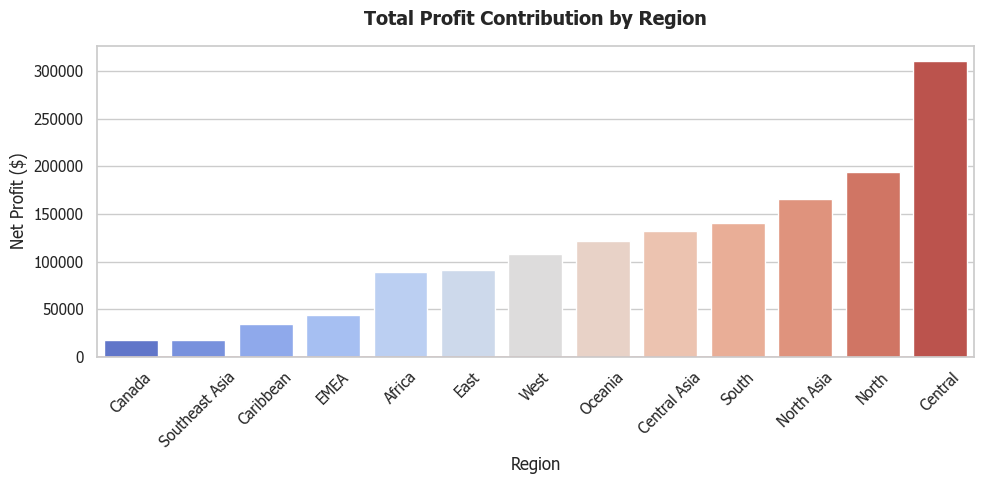

In [11]:
# Aggregate data by geographic region
region_analysis = df.groupby('region')[['sales', 'profit']].sum().sort_values(by='profit', ascending=True).reset_index()

# Plotting regional profitability
plt.figure(figsize=(10, 5))
sns.barplot(data=region_analysis, x='region', y='profit', palette='coolwarm')

# Visual cues for business context
plt.title('Total Profit Contribution by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Net Profit ($)', fontsize=12)
plt.axhline(0, color='red', linestyle='-', linewidth=1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Findings & Business Insights
* **The Southeast Asia Margin Crisis:** While other regions contribute healthy profits to the company, **Southeast Asia (SEA)** is barely breaking even despite having a substantial sales footprint.
* **Business Evaluation:** The sales team in the SEA region might be engaging in aggressive price wars or facing extremely high local logistics costs.
* **Strategic Transition to SQL:** This visual finding serves as our primary anchor. We will transition to targeted SQL queries to dissect the SEA region and isolate the root cause of this operational inefficiency.